# Preentrenamiento GPT-50M con datos locales

Entrena con `train.txt`, evalúa exclusivamente con `validation.txt` y registra `val_loss` cada 10 actualizaciones.

In [1]:
# Add wandb login and data savings, and we implement hella swag evaluation during training
#Add time measurements
#Use a lr scheduler
#Add Xavier Init
#Try 
#Probamos SwiGLU
# We try more depth and less attention heads as suggested in https://arxiv.org/pdf/2402.14905

In [2]:
%pip install -q wandb

Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
import subprocess
import sys
import time 


PROJECT_ROOT = Path("/workspace/notebooks")
assert (PROJECT_ROOT / "pyproject.toml").is_file(), f"No existe {PROJECT_ROOT / 'pyproject.toml'}"

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", "-e",
    f"{PROJECT_ROOT}[training]", "matplotlib"
])
print("Proyecto instalado desde:", PROJECT_ROOT)

Proyecto instalado desde: /workspace/notebooks


In [4]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import tiktoken

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from llm_mini_lab.models import GPTModel

from llm_mini_lab.evaluation import hellaswag

from llm_mini_lab.training import (
    GPT_CONFIG_50M,
    generate_text_simple,
    text_to_token_ids,
    token_ids_to_text,
    cosine_lr_multiplier, # The lr scheduler
    LocalTextDataset,
    init_xavier,
    evaluate,

 
   
)



if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("PyTorch:", torch.__version__)
print("Dispositivo:", device)
if device.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
Dispositivo: cuda
GPU: NVIDIA GeForce RTX 3060


In [5]:
import wandb


WANDB_RUN_ID = None

In [6]:
wandb.login()

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: volverman22 (volverman22-universidad-aut-noma-de-madrid) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [7]:
wandb_init_kwargs = {
    "project": "gpt2-50M",
    "name": "gpt2-50M-v4.4_More_depht"  # <-- Define aquí el nombre que aparecerá en W&B
}

if WANDB_RUN_ID:
    wandb_init_kwargs.update(id=WANDB_RUN_ID, resume="must")
    print(f"Resuming W&B run: {WANDB_RUN_ID}")

wandb.init(**wandb_init_kwargs)
wandb.define_metric("update")
wandb.define_metric("*", step_metric="update")


In [8]:
SEED = 123
MAX_LENGTH = 128
BATCH_SIZE = 2
MAX_TOKENS = 1_000_000
MAX_UPDATES = MAX_TOKENS // (BATCH_SIZE * MAX_LENGTH)
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.1
EVAL_INTERVAL = 10
VAL_BATCHES = 10

torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

print("Actualizaciones:", MAX_UPDATES)
print("Tokens previstos:", MAX_UPDATES * BATCH_SIZE * MAX_LENGTH)

Actualizaciones: 3906
Tokens previstos: 999936


In [9]:
DATA_DIR = PROJECT_ROOT / "data" / "smollm_local"
train_dataset = LocalTextDataset(DATA_DIR / "train.txt", MAX_LENGTH)
val_dataset = LocalTextDataset(DATA_DIR / "validation.txt", MAX_LENGTH)

loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
    num_workers=0, generator=loader_generator
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False,
    num_workers=0
)

xb, yb = next(iter(train_loader))
assert xb.shape == yb.shape == (BATCH_SIZE, MAX_LENGTH)
assert torch.equal(yb[:, :-1], xb[:, 1:])

print("Directorio de datos:", DATA_DIR)
print("Bloques de entrenamiento:", len(train_dataset))
print("Bloques de validación:", len(val_dataset))
print("Tokens de entrenamiento:", len(train_dataset.tokens))
print("Tokens de validación:", len(val_dataset.tokens))

Directorio de datos: /workspace/notebooks/data/smollm_local
Bloques de entrenamiento: 5235
Bloques de validación: 3162
Tokens de entrenamiento: 670193
Tokens de validación: 404795


In [10]:
GPT_CONFIG_50M = {
    "vocab_size": 50257,
    "context_length": 256,
    "emb_dim": 480,
    "n_heads": 4,          # antes: 8
    "n_layers": 9,         # antes: 7
    "drop_rate": 0.0,
    "qkv_bias": False,
    "ff_activation": "swiglu",
    "ff_hidden_dim": 1280, # antes: 1376
}
cfg = {
    **GPT_CONFIG_50M,
    "context_length": MAX_LENGTH,
    "ff_activation": "swiglu",
    "ff_hidden_dim": 1376,
}

model = GPTModel(cfg)
model = GPTModel(cfg)
model.apply(init_xavier)
model.out_head.weight = model.tok_emb.weight
model = model.to(device)

n_params = sum(parameter.numel() for parameter in model.parameters())
#assert n_params <= 50_000_000, f"El modelo tiene {n_params:,} parámetros"
print(f"Parámetros entrenables: {n_params:,} ({n_params / 1e6:.2f}M)")

optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)

Parámetros entrenables: 50,363,808 (50.36M)


In [11]:
HELLASWAG_EVAL_FREQ = 50

hellaswag_step = []
hellaswag_accuracy = []

In [12]:
WARMUP_STEPS = int(0.05 * MAX_UPDATES)  # 5 % del entrenamiento

scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda step: cosine_lr_multiplier(
        step=step,
        warmup_steps=WARMUP_STEPS,
        schedule_steps=MAX_UPDATES,
        min_lr_ratio=0.1,
    ),
)
        

In [13]:
model.train()



train_losses = []
val_losses = []
val_steps = []
tokens_seen = 0
update = 0
epoch = 0
tokenizer = tiktoken.get_encoding("gpt2")


t0 = time.perf_counter()
while update < MAX_UPDATES:
    epoch += 1
    print(f"Comenzando época {epoch}")

    for inputs, targets in train_loader:
        update += 1
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(inputs)
        loss = F.cross_entropy(logits.flatten(0, 1), targets.flatten())

        if not torch.isfinite(loss):
            raise FloatingPointError(f"Pérdida no finita en el paso {update}")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        train_losses.append(loss.item())
        tokens_seen += inputs.numel()

        current_lr = optimizer.param_groups[0]["lr"]
        
        wandb.log({"update": update, "tokens_seen": tokens_seen,
                   "train/loss": loss.item(), "train/lr":current_lr})

        if update % EVAL_INTERVAL == 0:
            mean_val_loss = evaluate(model, val_loader, VAL_BATCHES)
            val_steps.append(update)
            val_losses.append(mean_val_loss)
            wandb.log({"validation/loss": mean_val_loss})
            print(
                f"Step {update:04d}/{MAX_UPDATES} | "
                f"train_loss {loss.item():.4f} | val_loss {mean_val_loss:.4f}"
            )
            
        

        # Dentro del loop:
        if update % HELLASWAG_EVAL_FREQ == 0:
            hella = hellaswag.evaluate_hellaswag(
                model=model,
                tokenizer=tokenizer,
                device=device,
                max_examples=25,
            )
        
            hella_accuracy = hella["accuracy"]
        
            hellaswag_step.append(update)
            hellaswag_accuracy.append(hella_accuracy)
        
            wandb.log({
                "benchmark/hellaswag_accuracy": hella_accuracy,
                "benchmark/hellaswag_correct": hella["correct"],
                "benchmark/hellaswag_total": hella["total"],
            })
        
            print(
                f"HellaSwag: {hella_accuracy:.2%} "
                f"({hella['correct']}/{hella['total']})"
            )


        if update >= MAX_UPDATES:
            break
            
tf = time.perf_counter()
t = tf - t0
assert len(train_losses) == MAX_UPDATES
print(f"Entrenamiento completado: {tokens_seen:,} tokens en {epoch} época(s), tiempo: {t} segundos")

Comenzando época 1
Step 0010/3906 | train_loss 10.7271 | val_loss 10.7218
Step 0020/3906 | train_loss 10.5885 | val_loss 10.5830
Step 0030/3906 | train_loss 10.4624 | val_loss 10.4119
Step 0040/3906 | train_loss 10.2761 | val_loss 10.1817
Step 0050/3906 | train_loss 9.9241 | val_loss 9.8890


HellaSwag: 32.00% (8/25)
Step 0060/3906 | train_loss 9.4104 | val_loss 9.5322
Step 0070/3906 | train_loss 9.1150 | val_loss 9.1379
Step 0080/3906 | train_loss 9.0590 | val_loss 8.7662
Step 0090/3906 | train_loss 8.2816 | val_loss 8.4383
Step 0100/3906 | train_loss 8.3568 | val_loss 8.1898
HellaSwag: 24.00% (6/25)
Step 0110/3906 | train_loss 8.1478 | val_loss 8.0457
Step 0120/3906 | train_loss 7.9082 | val_loss 8.0099
Step 0130/3906 | train_loss 7.7765 | val_loss 7.9836
Step 0140/3906 | train_loss 7.8684 | val_loss 7.9661
Step 0150/3906 | train_loss 7.8439 | val_loss 7.9599
HellaSwag: 24.00% (6/25)
Step 0160/3906 | train_loss 8.1865 | val_loss 7.9483
Step 0170/3906 | train_loss 8.1427 | val_loss 7.9676
Step 0180/3906 | train_loss 7.8352 | val_loss 7.9583
Step 0190/3906 | train_loss 7.9989 | val_loss 7.9090
Step 0200/3906 | train_loss 7.8932 | val_loss 7.8911
HellaSwag: 24.00% (6/25)
Step 0210/3906 | train_loss 7.9586 | val_loss 7.8666
Step 0220/3906 | train_loss 8.2889 | val_loss 7.8453

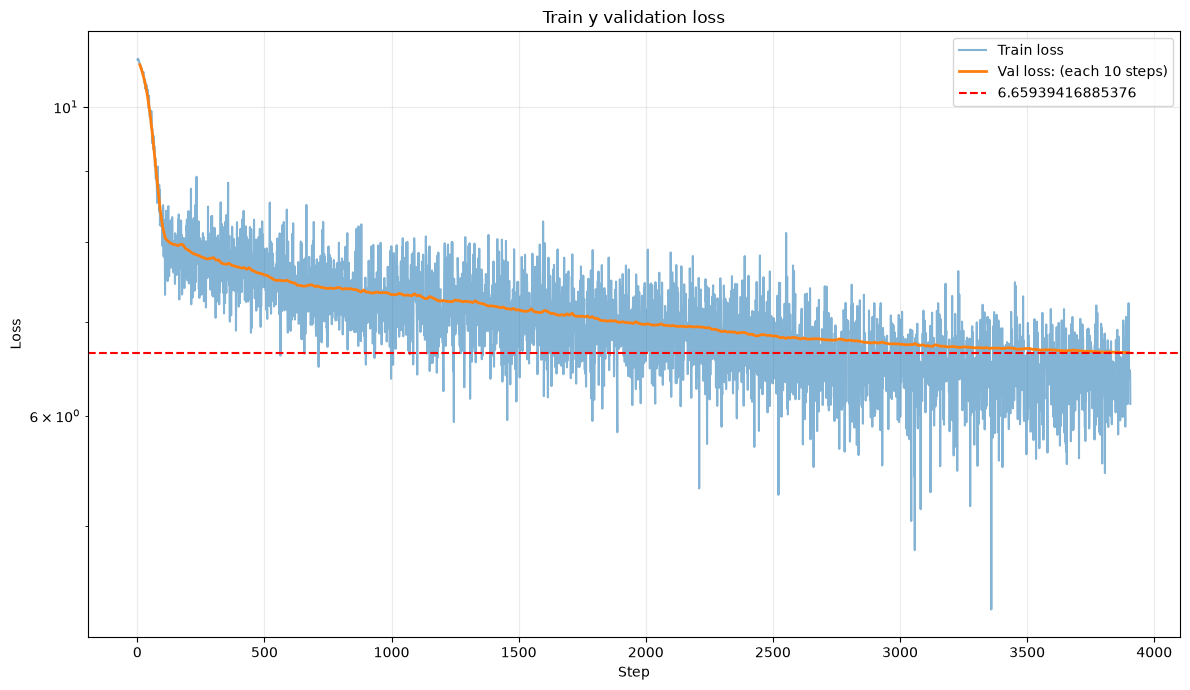

In [14]:
train_steps = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 7))
plt.plot(train_steps, train_losses, label="Train loss", alpha=0.55)
plt.plot(
    val_steps, val_losses, marker="", linewidth=2,
    label=f"Val loss: (each {EVAL_INTERVAL} steps)"
)
plt.axhline(y=val_losses[-1], color="r", linestyle="--", label=f"{val_losses[-1]}")
plt.title("Train y validation loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.yscale("log")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig("grafica_v3-limpio.png", dpi=300, bbox_inches="tight")

plt.show()

In [15]:

prompt = text_to_token_ids("Artificial intelligence", tokenizer).to(device)
generated_ids = generate_text_simple(
    model, prompt, max_new_tokens=20, context_size=MAX_LENGTH
)
print("Muestra:", token_ids_to_text(generated_ids.cpu(), tokenizer))

checkpoint_path = PROJECT_ROOT / "checkpoints" / "gpt-50m-local.pt"


wandb.save(str(checkpoint_path))
wandb.finish()
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "config": cfg,
    "updates": update,
    "tokens_seen": tokens_seen,
    "train_losses": train_losses,
    "val_steps": val_steps,
    "val_losses": val_losses,
}, checkpoint_path)
print("Checkpoint guardado en:", checkpoint_path)

wandb: WARNING Saving files without folders. If you want to preserve subdirectories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Muestra: Artificial intelligence, and the `                


benchmark/hellaswag_accuracy,█▅▅▄▄▄▂▄▂▇▅▇▅▅▄▇▇▄▇▄▅▄▂▅▁▅▄▂▄▄▂▁▂▂▄▁▂▅▄▄
benchmark/hellaswag_correct,▆▆▅▅█▅▁▅▃▁▆▆█▅▆█▅█▅▅▆▆▃▅▃▆▆▅▃▅▅▅▅▃▃▃▃▃▁▃
benchmark/hellaswag_total,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
tokens_seen,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇█
train/loss,█▇█▇▇▇▆▆▆▆▅▅▅▆▆▆▃▅▄▆▅▄▄▃▄▃▃▃▂▃▄▄▃▄▁▂▂▃▅▁
train/lr,▁▆███████▇▇▆▆▆▆▆▅▅▅▅▄▄▄▄▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▁
update,▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▅▅▅▆▇▇▇▇▇▇▇▇▇▇████
validation/loss,█▅▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
benchmark/hellaswag_accuracy,0.24
benchmark/hellaswag_correct,6
benchmark/hellaswag_total,25


Checkpoint guardado en: /workspace/notebooks/checkpoints/gpt-50m-local.pt
